# D14 · Region selection and evaluation must be independent

<!-- paper-first -->
### Research question

**Reading:** [PD04](../../curriculum/papers/design.md#pd04). Review the assigned figure or result before starting the lesson.

**Question:** Did the observations used to select a promising region also influence its reported evaluation?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

A region of interest can make a research question more specific, but does not automatically protect against bias. If you inspect a map, pick its strongest positive location, and report that location's effect from the same data, you preferentially select positive noise. This is a selection problem even if every individual voxel estimator was unbiased before selection. Renaming the selected cluster an ROI does not restore independence.

The notebook contains many synthetic studies with a true effect of zero at every location. For each study we generate discovery estimates and independent replication estimates with the same standard error. Selection chooses the most positive discovery location. The average selected discovery effect becomes positive, while the average independent replication effect at that same selected index remains near zero. Independence belongs to the selection rule and evaluated random variation, not to filenames or analysis-tool names.

Several designs can address the problem. An anatomical ROI defined without examining the tested effect may be appropriate if it matches the hypothesis. A separate localizer can select a functional region when its relevant noise and selection statistic are independent of the test. Splitting participants into discovery and evaluation sets provides another route but reduces the available sample in each part. Cross-fitting can use several held-out folds if all selection and preprocessing are confined to training folds and the final inference accounts for the procedure. A different contrast from the same dataset is not automatically independent.

Avoid another common overstatement: an independent ROI does not eliminate multiplicity when several ROIs, contrasts, or outcomes are tested. Nor does averaging within a region guarantee that the region is homogeneous or that its mean measures the intended mechanism. Spatial smoothing, misregistration, and atlas boundaries can alter which signal contributes. The transformation card should therefore describe how the region was defined, when its definition was frozen, what data influenced it, how signal was aggregated, and the family of hypotheses evaluated.

Predict whether selecting a maximum changes the mean effect under a global null.

Selected same-data / independent / predefined means: 0.5491461314893622 0.0002180378795551105 0.0019909070082208213


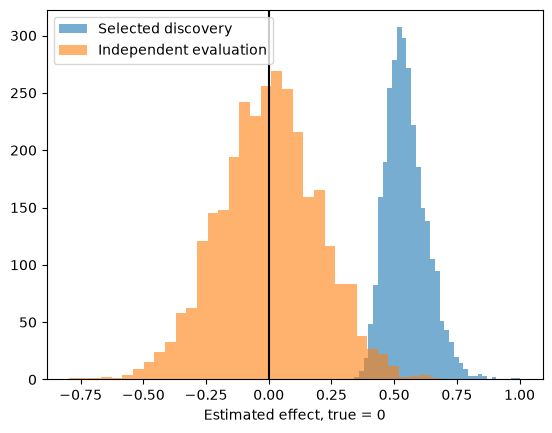

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng=np.random.default_rng(214)
replications,locations=3000,200
se=.2
discovery=rng.normal(0,se,size=(replications,locations))
validation=rng.normal(0,se,size=(replications,locations))
selected=discovery.argmax(axis=1);row=np.arange(replications)
same=discovery[row,selected];independent=validation[row,selected]
predefined=discovery[:,0]
assert same.mean()>.4
assert abs(independent.mean())<.02 and abs(predefined.mean())<.02
print('Selected same-data / independent / predefined means:',same.mean(),independent.mean(),predefined.mean())
plt.hist(same,bins=35,alpha=.6,label='Selected discovery')
plt.hist(independent,bins=35,alpha=.6,label='Independent evaluation')
plt.axvline(0,color='black');plt.xlabel('Estimated effect, true = 0');plt.legend();plt.show()

More searched locations provide more opportunities to select an upward fluctuation.

In [2]:
search_sizes=[1,10,50,200]
selected_means=np.array([discovery[:,:k].max(axis=1).mean() for k in search_sizes])
assert np.all(np.diff(selected_means)>=0)
print('Search size / mean selected effect:',list(zip(search_sizes,selected_means)))
wrong_validation_selection=validation.argmax(axis=1)
leaked=validation[row,wrong_validation_selection]
assert leaked.mean()>.4
print('Reselecting on validation recreates the bias:',leaked.mean())

Search size / mean selected effect: [(1, np.float64(0.0019909070082208213)), (10, np.float64(0.30764887258839385)), (50, np.float64(0.449291296047948)), (200, np.float64(0.5491461314893622))]
Reselecting on validation recreates the bias: 0.5510503569577226


## Supervise the AI, then transfer the idea

**AI prompt:** “Draw the boundary between selection data and evaluation data. Trace every learned ROI decision across that boundary. Ask me to predict the mean of a selected null location. Explain why a saved test set stops being independent if we reselect the best location on it.”

**Deliberate mistake:** choose the strongest discovery voxel and then choose the strongest validation voxel instead of evaluating the original index. That is another discovery search, not a replication. Transfer by preregistering anatomical masks or independent localizer rules, recording atlas/version/space, and checking overlap and aggregation. If reporting exploratory peaks, label them exploratory and avoid unbiased population-effect claims from selected same-data summaries. Deliver two analysis diagrams, one circular and one independent, plus a short explanation of what multiplicity remains even in the repaired design.

## Answer key — read after your own explanation

The same-data selected effect averages above .4 although truth is zero. Independent evaluation and the fixed location average near zero. Increasing the search set cannot lower a study's maximum, so selection bias grows. Selecting again in validation recreates the problem. Independence can be broken by earlier supervised feature selection, preprocessing, or repeated peeking even when the final regression is fitted separately.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [Kriegeskorte et al., Circular analysis in systems neuroscience](https://pmc.ncbi.nlm.nih.gov/articles/PMC2841687/); [DartBrains Multivariate Prediction](https://github.com/ljchang/dartbrains/blob/b72537ad25deee0281248a415a052cd87ff325de/content/Multivariate_Prediction.ipynb) for the related prediction context; [Berkeley projects](https://bic-berkeley.github.io/psych-214-fall-2016/projects.html) for replication-oriented coursework. See [the coverage and gaps](../../curriculum/design_coverage.md).

### Return to the research question

Revisit [PD04](../../curriculum/papers/design.md#pd04) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
